In [21]:
from sqlalchemy import create_engine, Column, Integer, String, Float, Date, func
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import random
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
engine = create_engine('sqlite:///sample_data.db')
Base = declarative_base()
Session = sessionmaker(bind=engine)
session = Session()

In [3]:
class Employee(Base):
    __tablename__ = 'employees'
    
    id = Column(Integer, primary_key=True)
    name = Column(String)
    age = Column(Integer)
    department = Column(String)
    salary = Column(Float)
    join_date = Column(Date)

Base.metadata.create_all(engine)


In [4]:
names = ['John', 'Alice', 'Bob', 'Emma', 'Liam', 'Sophia', 'Noah', 'Olivia']
departments = ['HR', 'Engineering', 'Marketing', 'Sales', 'Finance']

for _ in range(1000):
    employee = Employee(
        name=random.choice(names),
        age=random.randint(22, 60),
        department=random.choice(departments),
        salary=round(random.uniform(30000, 150000), 2),
        join_date=datetime.date(2015, 1, 1) + datetime.timedelta(days=random.randint(0, 365*8))
    )
    session.add(employee)

session.commit()


In [5]:

df_all = pd.read_sql("SELECT * FROM employees", engine)
print(df_all.head())


   id    name  age department     salary   join_date
0   1    Emma   45  Marketing   97454.87  2019-11-01
1   2    Liam   43      Sales  111802.93  2015-02-07
2   3  Sophia   54    Finance   37642.50  2022-05-08
3   4    Liam   48         HR  105582.57  2017-01-27
4   5    Emma   30      Sales  104181.52  2017-12-05


In [6]:
df_avg_salary = pd.read_sql("""
    SELECT department, AVG(salary) as avg_salary 
    FROM employees 
    GROUP BY department
""", engine)

    department    avg_salary
0  Engineering  91065.279742
1      Finance  88624.436548
2           HR  90182.321327
3    Marketing  89609.749198
4        Sales  88409.970995


C:\Users\ANKIT NAYAK\AppData\Local\Temp\ipykernel_8016\2596029572.py:11: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from current font.
  plt.tight_layout()
C:\Users\ANKIT NAYAK\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


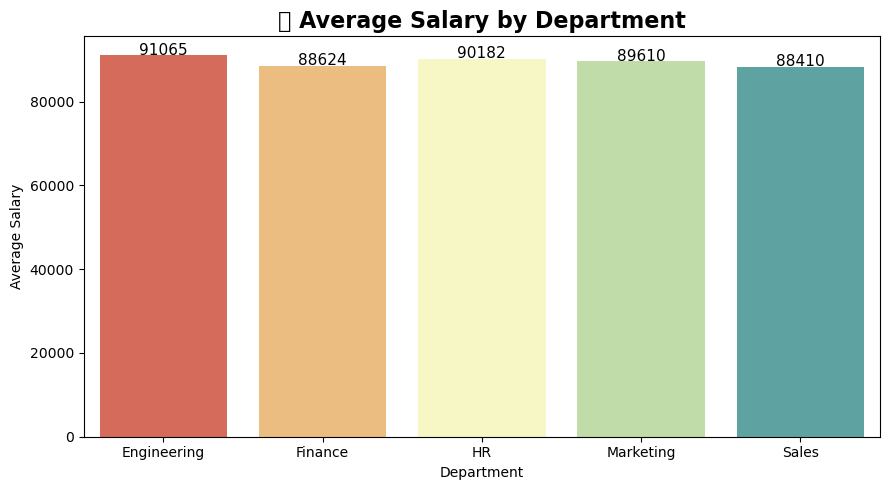

In [24]:
print(df_avg_salary) 
plt.figure(figsize=(9, 5))
colors = sns.color_palette("Spectral", len(df_avg_salary))
bars = sns.barplot(data=df_avg_salary, x='department', y='avg_salary', palette=colors)
plt.title("💼 Average Salary by Department", fontsize=16, fontweight='bold')
plt.ylabel("Average Salary")
plt.xlabel("Department")
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f'{bar.get_height():.0f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [27]:
df_top_paid = pd.read_sql("""
    SELECT name, department, salary , id
    FROM employees 
    ORDER BY salary DESC 
    LIMIT 10
""", engine)

     name   department     salary   id
0     Bob  Engineering  149977.27  928
1    Noah    Marketing  149871.84    8
2     Bob    Marketing  149677.96  879
3  Sophia           HR  149532.91  212
4    Noah      Finance  149519.61  794
5    Noah      Finance  149512.35   50
6  Olivia        Sales  149479.65   15
7    Emma    Marketing  149335.75  960
8    Liam  Engineering  149193.96  702
9    Liam        Sales  148865.83  349


C:\Users\ANKIT NAYAK\AppData\Local\Temp\ipykernel_8016\3950101792.py:11: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  plt.tight_layout()
C:\Users\ANKIT NAYAK\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


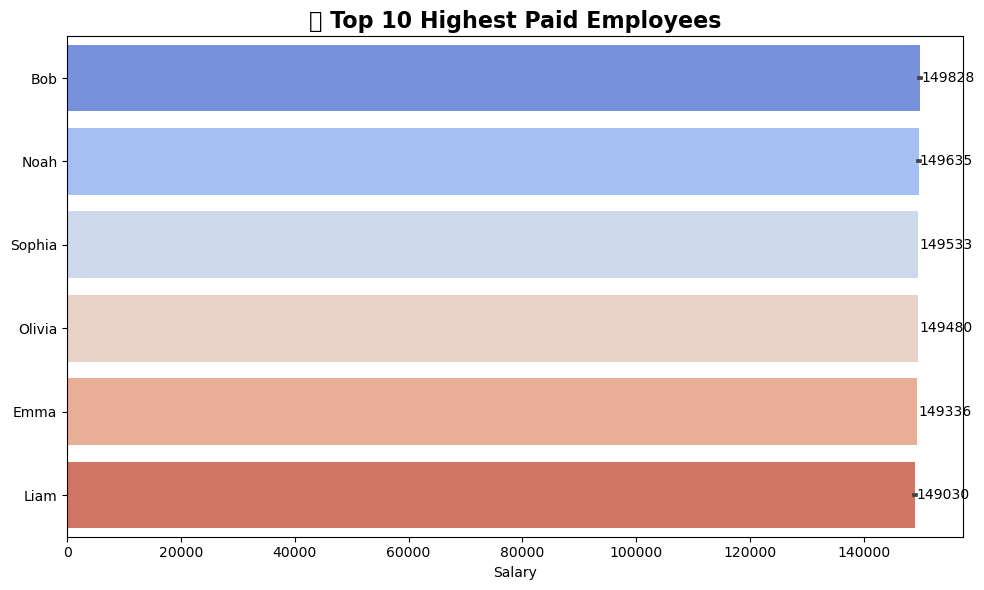

In [29]:
print(df_top_paid)
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=df_top_paid, y='name', x='salary', palette='coolwarm')
plt.title("💰 Top 10 Highest Paid Employees", fontsize=16, fontweight='bold')
plt.xlabel("Salary")
plt.ylabel("")

for bar in bars.patches:
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.0f}', va='center')
plt.tight_layout()
plt.show()


In [11]:
df_age_group = pd.read_sql("""
    SELECT 
        CASE 
            WHEN age < 30 THEN '<30'
            WHEN age BETWEEN 30 AND 40 THEN '30-40'
            WHEN age BETWEEN 41 AND 50 THEN '41-50'
            ELSE '51+' 
        END AS age_group,
        COUNT(*) as count
    FROM employees
    GROUP BY age_group
""", engine)

  age_group  count
0     30-40    303
1     41-50    244
2       51+    262
3       <30    191


C:\Users\ANKIT NAYAK\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


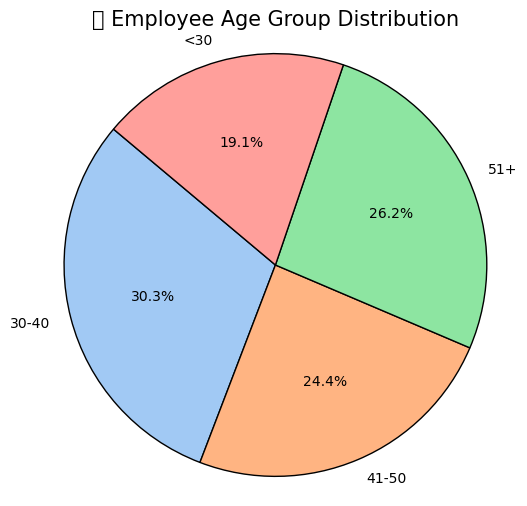

In [30]:
print(df_age_group)
plt.figure(figsize=(6, 6))
colors = sns.color_palette("pastel")
plt.pie(df_age_group['count'], labels=df_age_group['age_group'], autopct='%1.1f%%', startangle=140,
        colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title("👥 Employee Age Group Distribution", fontsize=15)
plt.axis('equal')
plt.show()

In [40]:
def run_query(title, query):
    print(f"\n🔍 Running Query: {title}\n")
    result = session.execute(query).fetchall()
    columns = session.execute(query).keys()
    df = pd.DataFrame(result, columns=columns)
    print(df.head())  
    return df

In [14]:
run_query("Running Average Salary Over Time (Window Function)",
"""
SELECT name, join_date, salary,
       ROUND(AVG(salary) OVER (ORDER BY join_date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW), 2) AS running_avg
FROM employees
ORDER BY join_date
LIMIT 20
""")


🔹 Running Average Salary Over Time (Window Function)
      name   join_date     salary  running_avg
0     Noah  2015-01-01   72989.87     72989.87
1     Liam  2015-01-02  128447.86    100718.87
2     Liam  2015-01-06  148469.93    116635.89
3   Olivia  2015-01-08   51615.73    100380.85
4      Bob  2015-01-12  123061.77    104917.03
5     John  2015-01-17   36162.03     97551.46
6     Noah  2015-01-17   66094.77     85080.85
7      Bob  2015-01-20   66314.36     68649.73
8   Sophia  2015-01-23   73010.39     72928.66
9     John  2015-01-25  146018.51     77520.01
10   Alice  2015-01-27   36505.59     77588.72
11  Olivia  2015-02-04  121167.53     88603.28
12    Liam  2015-02-07  111802.93     97700.99
13    John  2015-02-08  124679.46    108034.80
14    Liam  2015-02-09   93489.03     97528.91
15    John  2015-02-10  146271.36    119482.06
16    John  2015-02-10  114787.66    118206.09
17  Olivia  2015-02-14   81788.67    112203.24
18    John  2015-02-14   78260.90    102919.52
19  Ol

In [15]:
run_query("Department with the Highest Average Salary (Correlated Subquery)",
"""
SELECT department, AVG(salary) as avg_salary
FROM employees
GROUP BY department
HAVING avg_salary = (
    SELECT MAX(avg_sal) FROM (
        SELECT department, AVG(salary) AS avg_sal
        FROM employees
        GROUP BY department
    )
)
""")


🔹 Department with the Highest Average Salary (Correlated Subquery)
    department    avg_salary
0  Engineering  91065.279742



🔍 Running Query: Employees Who Earn More Than Department Average

    name   department     salary  dept_avg
0    Bob  Engineering  149977.27  91065.28
1   Liam  Engineering  149193.96  91065.28
2   John  Engineering  147460.79  91065.28
3  Alice  Engineering  147433.06  91065.28
4   Emma  Engineering  147378.87  91065.28
Columns in df_ranked: Index(['name', 'department', 'salary', 'dept_avg'], dtype='object')


C:\Users\ANKIT NAYAK\AppData\Local\Temp\ipykernel_8016\2788552610.py:23: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from current font.
  plt.tight_layout()
C:\Users\ANKIT NAYAK\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128188 (\N{BRIEFCASE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


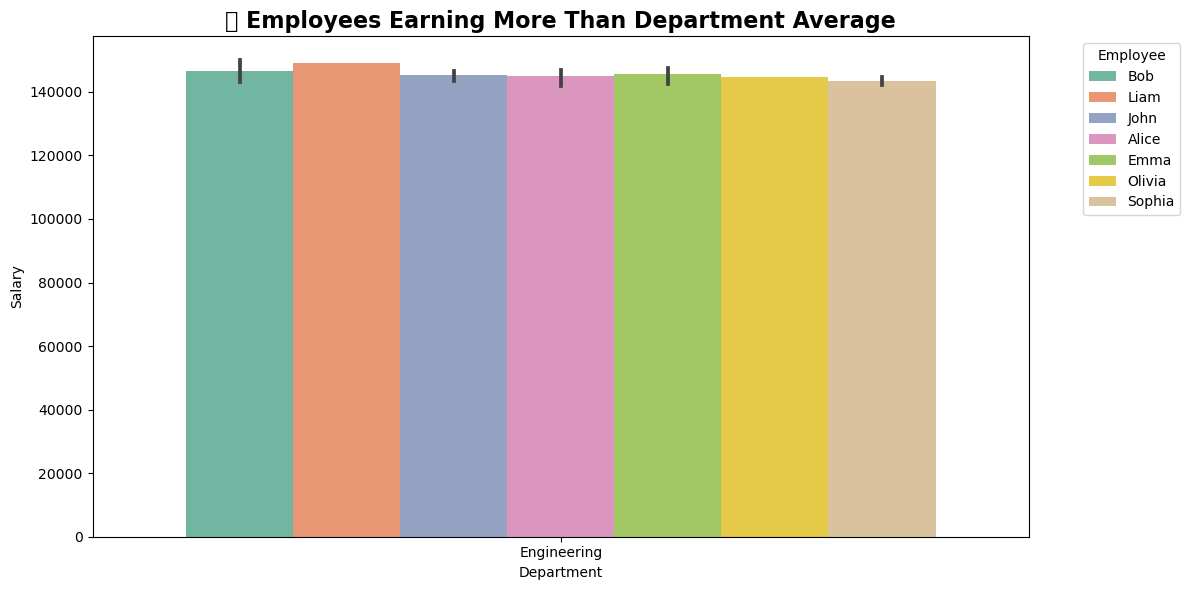

In [41]:
df_ranked = run_query("Employees Who Earn More Than Department Average",
"""
SELECT e.name, e.department, e.salary, ROUND(avg_dept, 2) AS dept_avg
FROM employees e
JOIN (
    SELECT department, AVG(salary) AS avg_dept
    FROM employees
    GROUP BY department
) d ON e.department = d.department
WHERE e.salary > avg_dept
ORDER BY e.department, e.salary DESC
LIMIT 20
""")

print("Columns in df_ranked:", df_ranked.columns)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_ranked, x='department', y='salary', hue='name', dodge=True, palette='Set2')
plt.title("💼 Employees Earning More Than Department Average", fontsize=16, fontweight='bold')
plt.ylabel("Salary")
plt.xlabel("Department")
plt.legend(title="Employee", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
run_query("Average Salary by Year of Joining",
"""
SELECT strftime('%Y', join_date) AS join_year, ROUND(AVG(salary), 2) AS avg_salary
FROM employees
GROUP BY join_year
ORDER BY join_year
""")


🔹 Average Salary by Year of Joining
  join_year  avg_salary
0      2015    89380.31
1      2016    92455.20
2      2017    91642.76
3      2018    90384.59
4      2019    87678.97
5      2020    89065.37
6      2021    87668.27
7      2022    87608.00


In [19]:
run_query("Salary Distribution by Age Buckets and Department",
"""
SELECT department,
       SUM(CASE WHEN age < 30 THEN 1 ELSE 0 END) AS under_30,
       SUM(CASE WHEN age BETWEEN 30 AND 40 THEN 1 ELSE 0 END) AS between_30_40,
       SUM(CASE WHEN age BETWEEN 41 AND 50 THEN 1 ELSE 0 END) AS between_41_50,
       SUM(CASE WHEN age > 50 THEN 1 ELSE 0 END) AS over_50
FROM employees
GROUP BY department
""")



🔹 Salary Distribution by Age Buckets and Department
    department  under_30  between_30_40  between_41_50  over_50
0  Engineering        40             63             36       55
1      Finance        24             59             65       49
2           HR        40             59             54       58
3    Marketing        48             57             39       43
4        Sales        39             65             50       57



🔍 Running Query: Top 3 Salaries per Department

   name   department     salary  rank
0   Bob  Engineering  149977.27     1
1  Liam  Engineering  149193.96     2
2  John  Engineering  147460.79     3
3  Noah      Finance  149519.61     1
4  Noah      Finance  149512.35     2


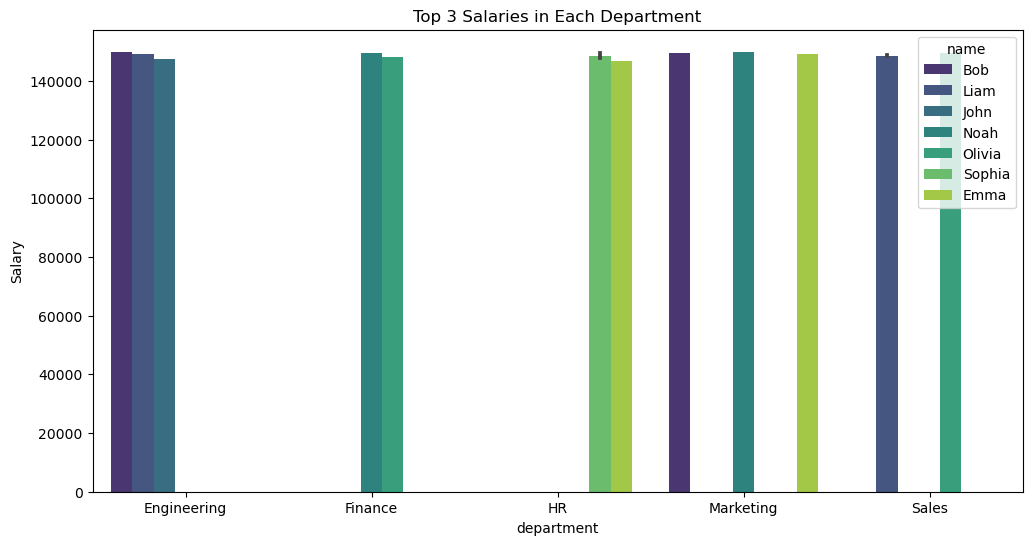

In [42]:
df_ranked = run_query("Top 3 Salaries per Department", """
SELECT * FROM (
    SELECT name, department, salary,
           RANK() OVER (PARTITION BY department ORDER BY salary DESC) as rank
    FROM employees
) WHERE rank <= 3
""")
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ranked, x='department', y='salary', hue='name', dodge=True, palette="viridis")
plt.title("Top 3 Salaries in Each Department")
plt.ylabel("Salary")
plt.show()


🔍 Running Query: Salary Distribution by Age Buckets and Department

    department  under_30  between_30_40  between_41_50  over_50
0  Engineering        40             63             36       55
1      Finance        24             59             65       49
2           HR        40             59             54       58
3    Marketing        48             57             39       43
4        Sales        39             65             50       57


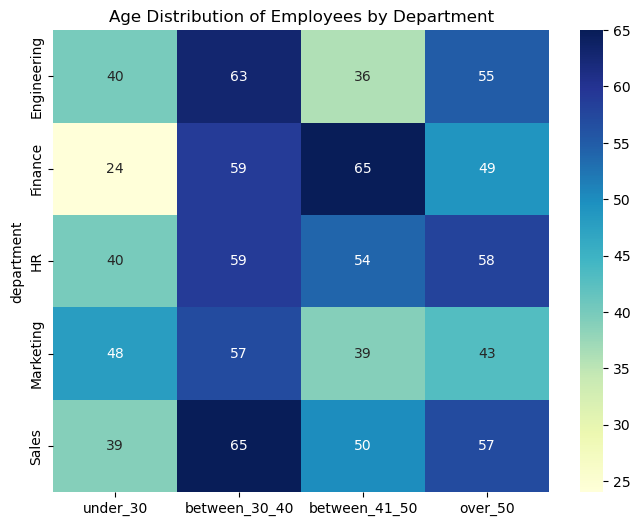

In [43]:
df_pivot = run_query("Salary Distribution by Age Buckets and Department", """
SELECT department,
       SUM(CASE WHEN age < 30 THEN 1 ELSE 0 END) AS under_30,
       SUM(CASE WHEN age BETWEEN 30 AND 40 THEN 1 ELSE 0 END) AS between_30_40,
       SUM(CASE WHEN age BETWEEN 41 AND 50 THEN 1 ELSE 0 END) AS between_41_50,
       SUM(CASE WHEN age > 50 THEN 1 ELSE 0 END) AS over_50
FROM employees
GROUP BY department
""")
df_pivot.set_index('department', inplace=True)
plt.figure(figsize=(8, 6))
sns.heatmap(df_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Age Distribution of Employees by Department")
plt.show()